In [1]:
# ── Cell 1: Setup + Check Paths ──
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, recall_score, precision_score,
                             classification_report, confusion_matrix)

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")

# check all input paths
print("\nInput files:")
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    if level < 4:
        indent = '   ' * level
        print(f"{indent}{os.path.basename(root)}/")
        for file in sorted(files)[:5]:
            print(f"{indent}   {file}")

Device : cuda
GPU    : Tesla T4

Input files:
input/
   datasets/
      kmader/
         skin-cancer-mnist-ham10000/
            HAM10000_metadata.csv
            hmnist_28_28_L.csv
            hmnist_28_28_RGB.csv
            hmnist_8_8_L.csv
            hmnist_8_8_RGB.csv
   notebooks/
      shaiknazeerhasan/
         cnn-with-pytorch/
            __notebook__.ipynb
            __output__.json
            __results__.html
            best_model.pt
            custom.css


In [2]:
# ── Cell 2: Load Data + Model ──
DATA_DIR  = Path('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000')
IMG_DIR_1 = DATA_DIR / 'ham10000_images_part_1'
IMG_DIR_2 = DATA_DIR / 'ham10000_images_part_2'
MODEL_PATH = '/kaggle/input/notebooks/shaiknazeerhasan/cnn-with-pytorch/best_model.pt'

# label map
LABEL_MAP   = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
CLASS_NAMES = list(LABEL_MAP.keys())
NUM_CLASSES = len(CLASS_NAMES)

# load metadata
df = pd.read_csv(DATA_DIR / 'HAM10000_metadata.csv')
df['label'] = df['dx'].map(LABEL_MAP)

# map image paths
def get_image_path(image_id):
    for d in [IMG_DIR_1, IMG_DIR_2]:
        p = d / f"{image_id}.jpg"
        if p.exists(): return str(p)
    return None

df['path'] = df['image_id'].apply(get_image_path)

# same split as training — reproducible
_, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
_, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])
print(f"Test samples : {len(test_df)}")

# transform — same as val/test in training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# dataset
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

test_ds     = SkinDataset(test_df, transform=transform)
test_loader = DataLoader(test_ds, batch_size=16,
                         shuffle=False, num_workers=2)
print(f"Test batches : {len(test_loader)}")

# load model
model = models.efficientnet_b4(weights=None)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, NUM_CLASSES
)
state_dict = torch.load(MODEL_PATH, map_location=device)

# handle DataParallel prefix
if any(k.startswith('module.') for k in state_dict.keys()):
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

model.load_state_dict(state_dict)
model = model.to(device)
model.eval()
print(f"\nModel loaded ✅")
print(f"Device       : {device}")

Test samples : 1503
Test batches : 94

Model loaded ✅
Device       : cuda


In [3]:
# ── Cell 3: Full Evaluation ──
all_preds  = []
all_labels = []
all_probs  = []

print("Running inference on test set...")
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# metrics
test_acc    = (all_preds == all_labels).mean()
test_f1     = f1_score(all_labels, all_preds, average='macro', zero_division=0)
test_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
test_prec   = precision_score(all_labels, all_preds, average='macro', zero_division=0)
mel_recall  = recall_score(all_labels, all_preds, average=None, zero_division=0)[1]

print(f"\n{'='*60}")
print(f"TEST SET RESULTS")
print(f"{'='*60}")
print(f"Accuracy       : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Macro F1       : {test_f1:.4f}")
print(f"Macro Recall   : {test_recall:.4f}")
print(f"Macro Precision: {test_prec:.4f}")
print(f"Melanoma Recall: {mel_recall:.4f}")

print(f"\n{'='*60}")
print(f"CLASSIFICATION REPORT (per class)")
print(f"{'='*60}")
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    zero_division=0
))

Running inference on test set...

TEST SET RESULTS
Accuracy       : 0.8589 (85.89%)
Macro F1       : 0.7924
Macro Recall   : 0.8105
Macro Precision: 0.7813
Melanoma Recall: 0.7665

CLASSIFICATION REPORT (per class)
              precision    recall  f1-score   support

          nv       0.94      0.90      0.92      1006
         mel       0.62      0.77      0.68       167
         bkl       0.75      0.79      0.77       165
         bcc       0.79      0.84      0.82        77
       akiec       0.75      0.67      0.71        49
        vasc       0.81      1.00      0.90        22
          df       0.80      0.71      0.75        17

    accuracy                           0.86      1503
   macro avg       0.78      0.81      0.79      1503
weighted avg       0.87      0.86      0.86      1503



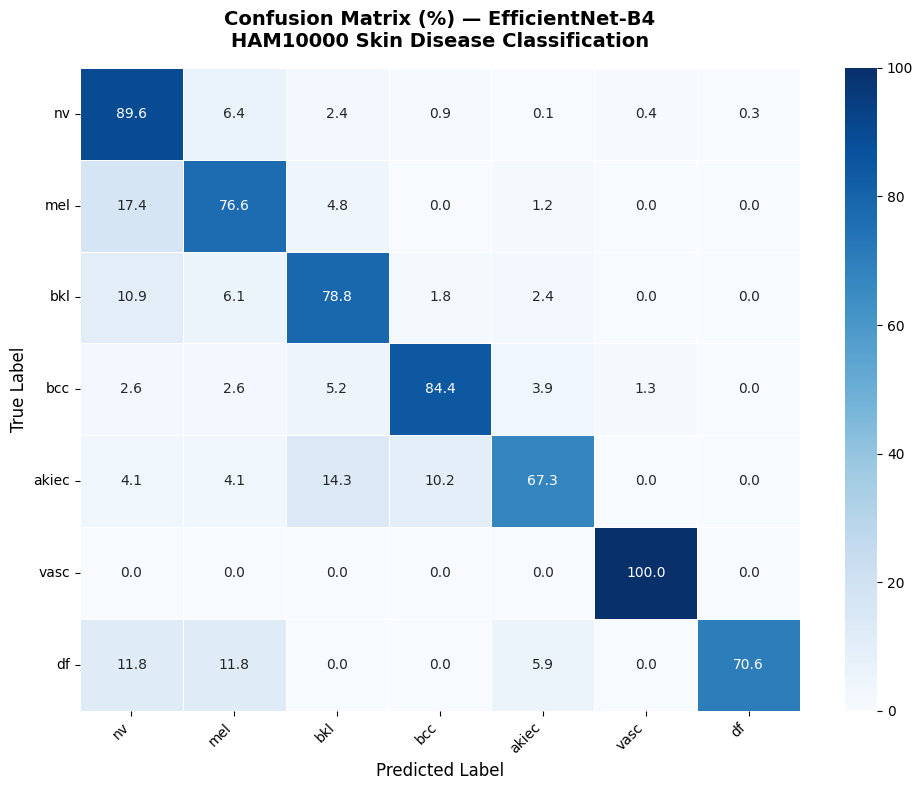

Confusion matrix saved ✅


In [4]:
# ── Cell 4: Confusion Matrix ──
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title('Confusion Matrix (%) — EfficientNet-B4\nHAM10000 Skin Disease Classification',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved ✅")

Generating Grad-CAM heatmaps...


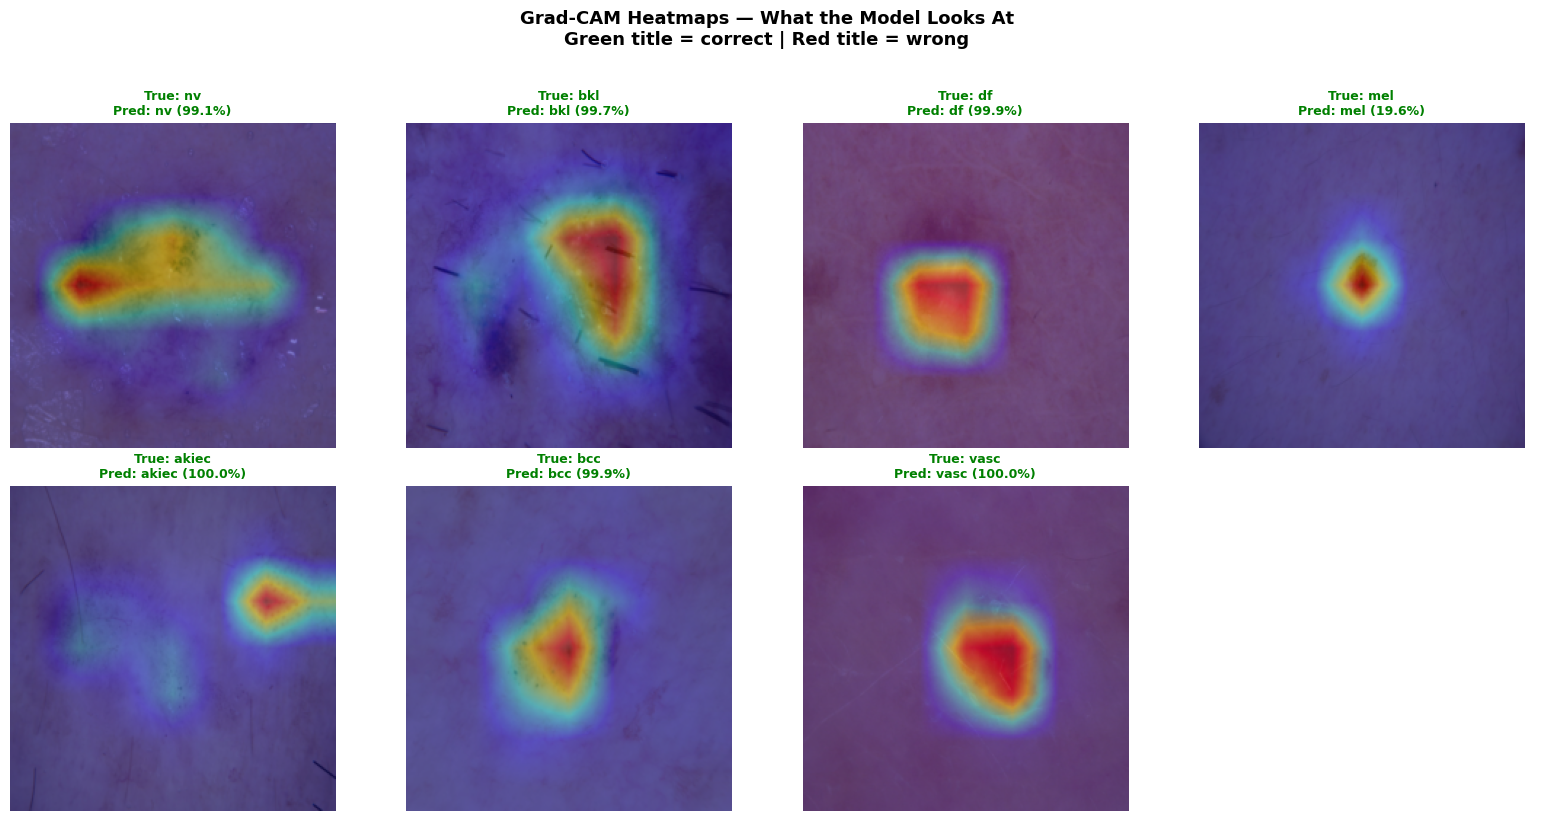

Grad-CAM saved ✅


In [5]:
# ── Cell 5: Grad-CAM Heatmaps ──
from torch.nn import functional as F
import cv2

def get_gradcam(model, image_tensor, target_class=None):
    model.eval()
    features     = []
    gradients    = []

    # hook into last conv layer of EfficientNet-B4
    def forward_hook(module, input, output):
        features.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # EfficientNet-B4 last conv block
    target_layer = model.features[-1]
    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    # forward pass
    image_tensor = image_tensor.unsqueeze(0).to(device)
    output       = model(image_tensor)

    if target_class is None:
        target_class = output.argmax(dim=1).item()

    # backward pass
    model.zero_grad()
    output[0, target_class].backward()

    # compute grad-cam
    grads    = gradients[0].squeeze(0)
    feats    = features[0].squeeze(0)
    weights  = grads.mean(dim=(1, 2))
    cam      = (weights[:, None, None] * feats).sum(dim=0)
    cam      = F.relu(cam)
    cam      = cam - cam.min()
    cam      = cam / (cam.max() + 1e-8)
    cam      = cam.detach().cpu().numpy()

    fh.remove()
    bh.remove()

    return cam, target_class, output.softmax(dim=1)[0].detach().cpu().numpy()


def show_gradcam(image_tensor, cam, true_label, pred_label, confidence, ax):
    # denormalize image
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = image_tensor.permute(1, 2, 0).numpy()
    img  = std * img + mean
    img  = np.clip(img, 0, 1)

    # resize cam to image size
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap     = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay     = 0.5 * img + 0.4 * heatmap
    overlay     = np.clip(overlay, 0, 1)

    ax.imshow(overlay)
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(
        f"True: {CLASS_NAMES[true_label]}\n"
        f"Pred: {CLASS_NAMES[pred_label]} ({confidence:.1%})",
        color=color, fontsize=9, fontweight='bold'
    )
    ax.axis('off')


# plot grad-cam for sample images — one per class
print("Generating Grad-CAM heatmaps...")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

shown_classes = set()
sample_idx    = 0

for idx in range(len(test_ds)):
    img_tensor, label = test_ds[idx]
    if label in shown_classes:
        continue

    cam, pred_class, probs = get_gradcam(model, img_tensor, target_class=label)
    confidence            = probs[pred_class]

    show_gradcam(
        img_tensor, cam, label, pred_class,
        confidence, axes[sample_idx]
    )
    shown_classes.add(label)
    sample_idx += 1

    if sample_idx == 7:
        break

# hide last empty subplot
axes[7].axis('off')

plt.suptitle(
    'Grad-CAM Heatmaps — What the Model Looks At\n'
    'Green title = correct | Red title = wrong',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_heatmaps.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM saved ✅")